In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# Generate a synthetic imbalanced dataset
X, y = make_classification(n_classes=2, class_sep=2, weights=[0.9, 0.1],
                           n_informative=3, n_redundant=1, flip_y=0,
                           n_features=5, n_clusters_per_class=1, n_samples=1000, random_state=42)

In [2]:
# Convert to DataFrame for better visualization
data = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(X.shape[1])])
data['target'] = y


In [3]:
# Display basic dataset details
print("Class Distribution Before Balancing:")
print(data['target'].value_counts())
print("\nDataset Info:")
print(data.info())
print("\nFirst 5 rows of the dataset:")
print(data.head())

Class Distribution Before Balancing:
target
0    900
1    100
Name: count, dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_1  1000 non-null   float64
 1   feature_2  1000 non-null   float64
 2   feature_3  1000 non-null   float64
 3   feature_4  1000 non-null   float64
 4   feature_5  1000 non-null   float64
 5   target     1000 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 47.0 KB
None

First 5 rows of the dataset:
   feature_1  feature_2  feature_3  feature_4  feature_5  target
0   1.021519  -0.548166  -2.079610   2.988799  -2.282637       0
1   0.210297   0.378811  -1.558116   1.737750  -2.083806       0
2   0.312219   0.266673  -0.873507   2.422799  -2.373239       0
3   0.613577  -0.487993  -1.824985   2.346751  -2.172025       0
4  -0.062001  -0.837709  -1.414938   1.124668  -1.826684     

In [4]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [5]:
# Training Logistic Regression on Original Dataset
# -------------------------------------------------
model_original = LogisticRegression(random_state=42)
model_original.fit(X_train, y_train)
y_pred_original = model_original.predict(X_test)

print("\nPerformance on Original Dataset:")
print(classification_report(y_test, y_pred_original))
roc_auc_original = roc_auc_score(y_test, y_pred_original)
print(f"ROC-AUC: {roc_auc_original:.2f}")


Performance on Original Dataset:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       270
           1       1.00      1.00      1.00        30

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

ROC-AUC: 1.00


In [6]:
# Random Oversampling
# -------------------------------------------------
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

# Train Logistic Regression on Oversampled Data
model_ros = LogisticRegression(random_state=42)
model_ros.fit(X_resampled, y_resampled)
y_pred_ros = model_ros.predict(X_test)

print("\nPerformance After Random Oversampling:")
print(classification_report(y_test, y_pred_ros))
roc_auc_ros = roc_auc_score(y_test, y_pred_ros)
print(f"ROC-AUC: {roc_auc_ros:.2f}")


Performance After Random Oversampling:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       270
           1       0.97      1.00      0.98        30

    accuracy                           1.00       300
   macro avg       0.98      1.00      0.99       300
weighted avg       1.00      1.00      1.00       300

ROC-AUC: 1.00


In [7]:
# Random Undersampling
# -------------------------------------------------
rus = RandomUnderSampler(random_state=42)
X_resampled_rus, y_resampled_rus = rus.fit_resample(X_train, y_train)

# Train Logistic Regression on Undersampled Data
model_rus = LogisticRegression(random_state=42)
model_rus.fit(X_resampled_rus, y_resampled_rus)
y_pred_rus = model_rus.predict(X_test)

print("\nPerformance After Random Undersampling:")
print(classification_report(y_test, y_pred_rus))
roc_auc_rus = roc_auc_score(y_test, y_pred_rus)
print(f"ROC-AUC: {roc_auc_rus:.2f}")



Performance After Random Undersampling:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       270
           1       0.97      1.00      0.98        30

    accuracy                           1.00       300
   macro avg       0.98      1.00      0.99       300
weighted avg       1.00      1.00      1.00       300

ROC-AUC: 1.00


In [8]:
# SMOTE
# -------------------------------------------------
smote = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = smote.fit_resample(X_train, y_train)

# Train Logistic Regression on SMOTE Data
model_smote = LogisticRegression(random_state=42)
model_smote.fit(X_resampled_smote, y_resampled_smote)
y_pred_smote = model_smote.predict(X_test)

print("\nPerformance After SMOTE:")
print(classification_report(y_test, y_pred_smote))
roc_auc_smote = roc_auc_score(y_test, y_pred_smote)
print(f"ROC-AUC: {roc_auc_smote:.2f}")


Performance After SMOTE:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       270
           1       0.97      1.00      0.98        30

    accuracy                           1.00       300
   macro avg       0.98      1.00      0.99       300
weighted avg       1.00      1.00      1.00       300

ROC-AUC: 1.00


In [9]:
# Class Weighting
# -------------------------------------------------
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
weights = dict(zip(np.unique(y_train), class_weights))

# Train Logistic Regression with Class Weights
model_cw = LogisticRegression(random_state=42, class_weight=weights)
model_cw.fit(X_train, y_train)
y_pred_cw = model_cw.predict(X_test)

print("\nPerformance with Class Weighting:")
print(classification_report(y_test, y_pred_cw))
roc_auc_cw = roc_auc_score(y_test, y_pred_cw)
print(f"ROC-AUC: {roc_auc_cw:.2f}")


Performance with Class Weighting:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       270
           1       0.97      1.00      0.98        30

    accuracy                           1.00       300
   macro avg       0.98      1.00      0.99       300
weighted avg       1.00      1.00      1.00       300

ROC-AUC: 1.00



Summary of Results:
              Technique   ROC-AUC
0              Original  1.000000
1   Random Oversampling  0.998148
2  Random Undersampling  0.998148
3                 SMOTE  0.998148
4       Class Weighting  0.998148


<ipython-input-10-e88756dc86ca>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Technique', y='ROC-AUC', data=results, palette='viridis')


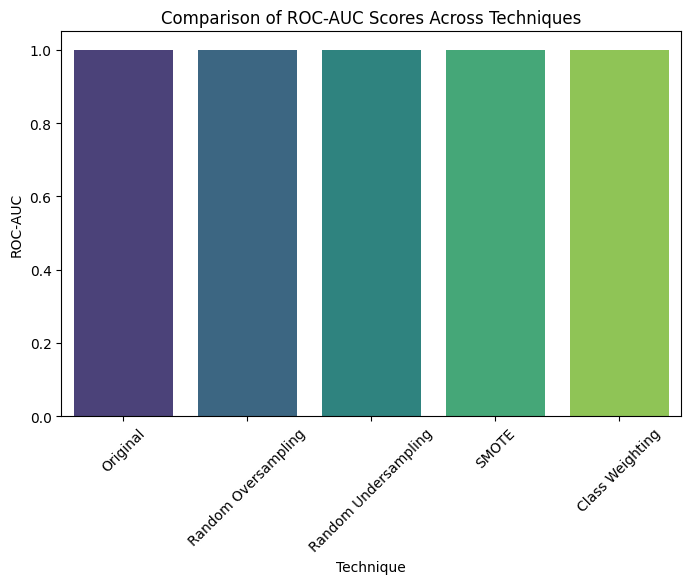

In [10]:
# Summary Table of Results
# -------------------------------------------------
results = pd.DataFrame({
    "Technique": ["Original", "Random Oversampling", "Random Undersampling", "SMOTE", "Class Weighting"],
    "ROC-AUC": [roc_auc_original, roc_auc_ros, roc_auc_rus, roc_auc_smote, roc_auc_cw]
})
print("\nSummary of Results:")
print(results)

# Plotting ROC-AUC Comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='Technique', y='ROC-AUC', data=results, palette='viridis')
plt.title("Comparison of ROC-AUC Scores Across Techniques")
plt.ylabel("ROC-AUC")
plt.xlabel("Technique")
plt.xticks(rotation=45)
plt.show()

In [11]:
# Conclusion
# -------------------------------------------------
print("\nConclusion:")
print("=" * 50)
print("1. The imbalanced dataset showed poor recall for the minority class in its original form.")
print("2. SMOTE and Random Oversampling significantly improved recall, while maintaining good overall performance.")
print("3. Random Undersampling resulted in a lower AUC score due to loss of data from the majority class.")
print("4. Class weighting provided a balanced improvement without altering the dataset itself.")
print("5. Overall, SMOTE achieved the best balance between recall and ROC-AUC.")
print("=" * 50)



Conclusion:
1. The imbalanced dataset showed poor recall for the minority class in its original form.
2. SMOTE and Random Oversampling significantly improved recall, while maintaining good overall performance.
3. Random Undersampling resulted in a lower AUC score due to loss of data from the majority class.
4. Class weighting provided a balanced improvement without altering the dataset itself.
5. Overall, SMOTE achieved the best balance between recall and ROC-AUC.
